# QKD with no eavesdropper

First, a note on quantum simulators: Most quantum problems involving more than ~30 qubits cannot be simulated by most computers. No classical computer, supercomputer or GPU can simulate the full range of behavior of a 127-qubit quantum computer. Usually, the motivation for using real quantum computers is that the many entangled qubits cannot be simulated. In this case, there is no entanglement of qubits, unless we use the teleportation scheme to move information. In this case, the motivation for using real quantum computers is different: it is the no-cloning theorem. A classical computer simulating a qubit could send information about a quantum state from Alice to Bob, but if this classical information were intercepted, it could easily be duplicated, and Eve could keep a perfect copy, while sending another to Bob. This is not possible with real quantum states.

IBM Quantum recommends tackling quantum computing problems using a framework we call "Qiskit patterns". It consists of the following steps.

- Step 1: Map your problem to a quantum circuit
- Step 2: Optimize your circuit for running on real quantum hardware
- Step 3: Execute your job on IBM quantum computers using Runtime primitives
- Step 4: Post-process the results

### Qiskit patterns step 1: Map your problem to a quantum circuit

In [1]:
# Qiskit patterns step 1: Map your problem to quantum circuit
# Import some generic packages

import numpy as np
from qiskit import QuantumCircuit

# Set up a random number generator and a quantum circuit. We choose to start with 20 bits, though any number <30 should be fine.

rng = np.random.default_rng()
bit_num = 20
qc = QuantumCircuit(bit_num, bit_num)

# QKD step 1: Random bits and bases for Alice
# generate Alice's random bits

abits = np.round(rng.random(bit_num))

# generate Alice's random measurement bases. Here we will associate a "0" with the Z basis, and a "1" with the X basis.

abase = np.round(rng.random(bit_num))

# Alice's state preparation. Check that this creates states according to table 1

for n in range(bit_num):
    if abits[n] == 0:
        if abase[n] == 1:
            qc.h(n)
    if abits[n] == 1:
        if abase[n] == 0:
            qc.x(n)
        if abase[n] == 1:
            qc.x(n)
            qc.h(n)

qc.barrier()

# QKD step 2: Random bases for Bob
# generate Bob's random measurement bases.

bbase = np.round(rng.random(bit_num))

# Note that if Bob measures in Z no gates are necessary, since IBM Quantum computers measure in Z by default.
# If Bob measures in the X basis, we implement a hadamard gate qc.h to facilitate the measurement.

for m in range(bit_num):
    if bbase[m] == 1:
        qc.h(m)
    qc.measure(m, m)

Alice's bits are  [1. 1. 0. 1. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 1. 1. 1. 1. 1. 1.]
Alice's bases are  [1. 1. 1. 1. 1. 1. 0. 0. 1. 0. 1. 0. 0. 1. 1. 0. 1. 0. 1. 0.]
Bob's bases are  [1. 0. 1. 0. 1. 0. 0. 0. 1. 0. 1. 0. 1. 0. 1. 1. 0. 0. 0. 1.]


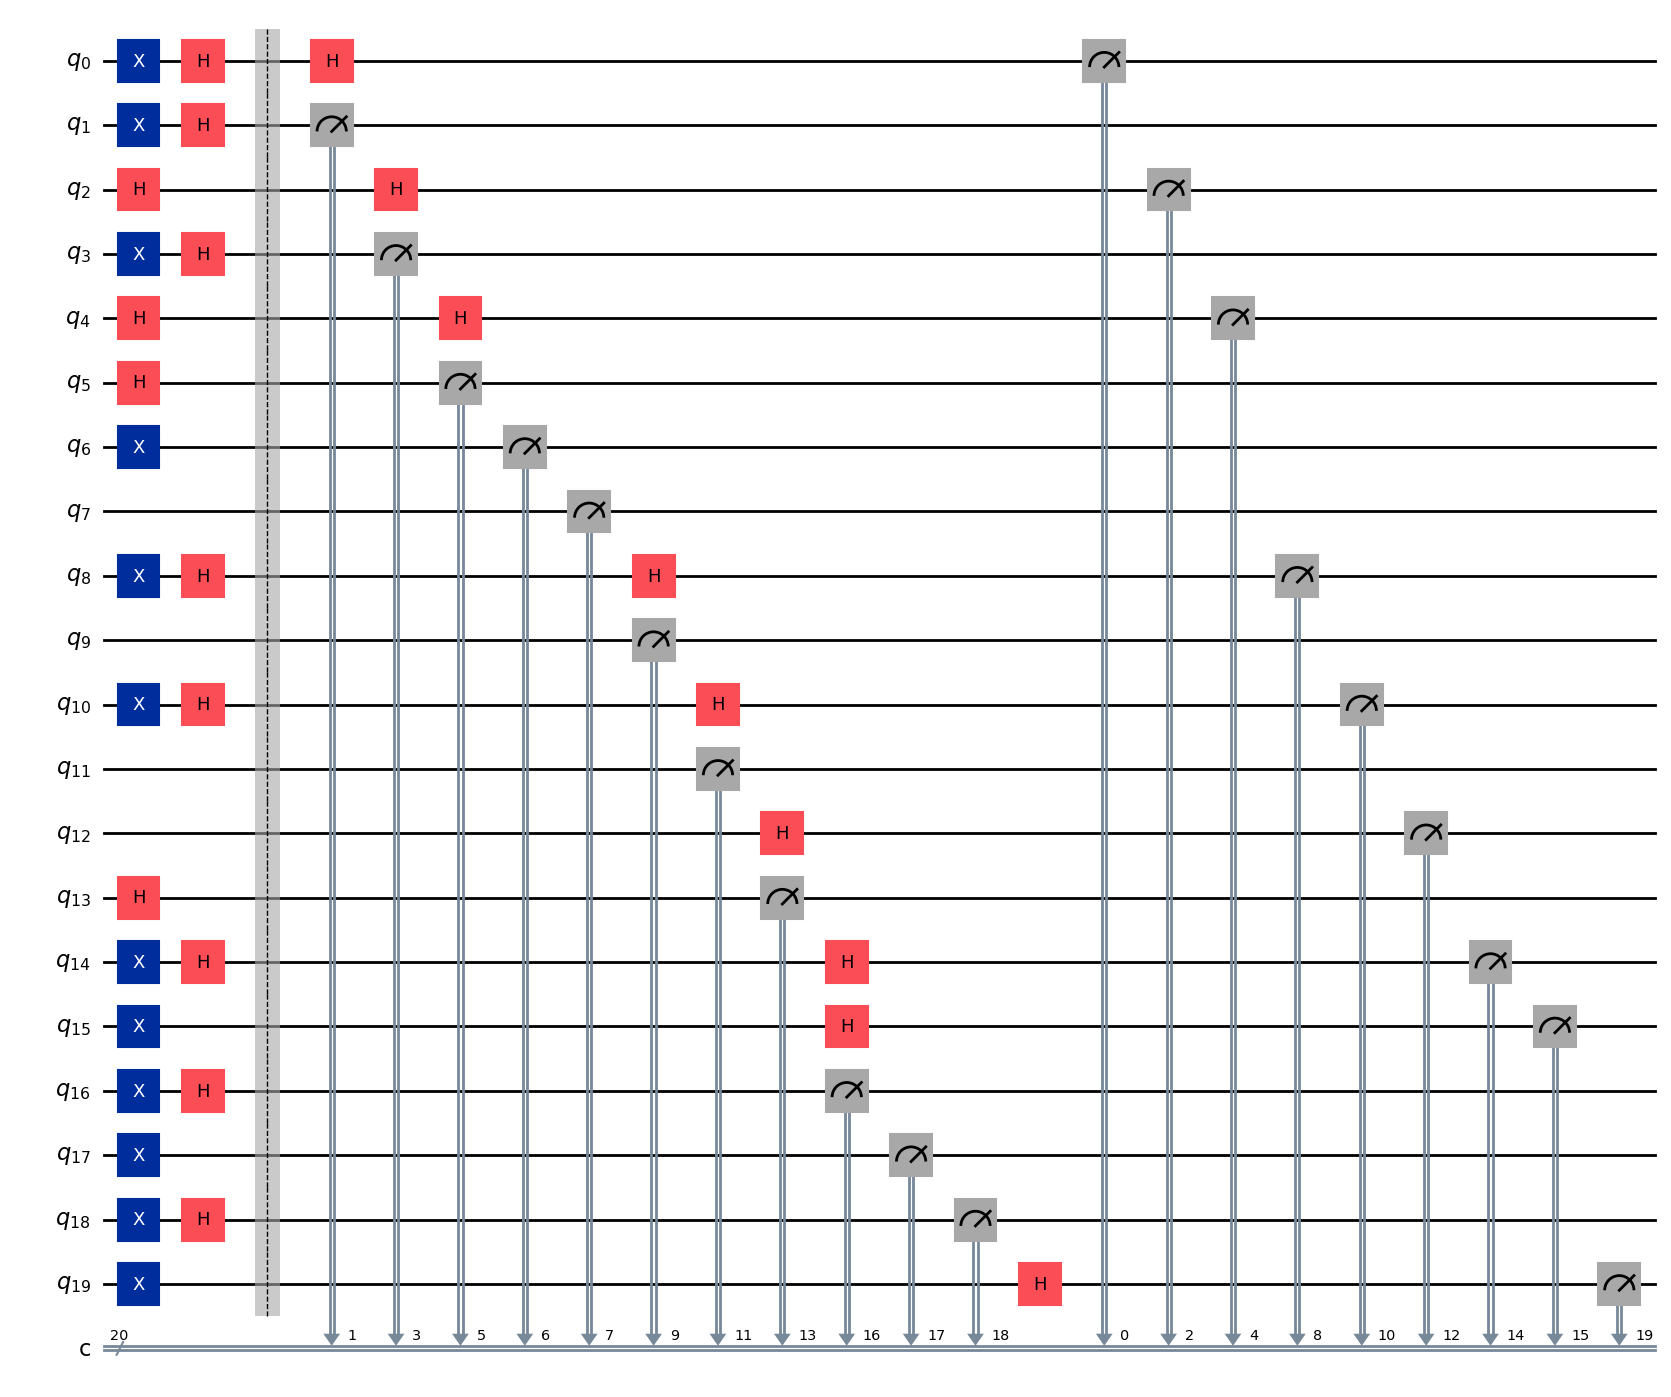

In [2]:
print("Alice's bits are ", abits)
print("Alice's bases are ", abase)
print("Bob's bases are ", bbase)
qc.draw("mpl")

### Qiskit patterns step 2: Optimize problem for quantum execution

This step takes the operations we want to perform and expresses them in terms of the functionality of a specific quantum computer. It also maps our problem onto the layout of the quantum computer.

We will start by loading several packages that are required to communicate with IBM quantum computers. We must also select a backend on which to run. We can either choose the least busy backend, or select a specific backend whose properties we know. Although we will momentarily use a simulator, it is important to use a reasonable noise model in simulation, and it is good to keep the workflow as close as possible to what we will use later for real quantum computers.

In [3]:
# Load the Qiskit Runtime service
from qiskit_ibm_runtime import QiskitRuntimeService

# Load the Qiskit Runtime service

# Syntax for first saving your token.  Delete these lines after saving your credentials.
# QiskitRuntimeService.save_account(channel='ibm_quantum_platform', instance = '<YOUR_IBM_INSTANCE_CRN>', token='<YOUR-API_KEY>', overwrite=True, set_as_default=True)
# service = QiskitRuntimeService(channel='ibm_quantum_platform')

# Load saved credentials
service = QiskitRuntimeService()


# Use the least busy backend, or uncomment the loading of a specific backend like "ibm_brisbane".
backend = service.least_busy(operational=True, simulator=False, min_num_qubits = 127)
# backend = service.backend("ibm_brisbane")
print(backend.name)

ibm_marrakesh


In [4]:
# Load the backend sampler
from qiskit.primitives import BackendSamplerV2

# Load the Aer simulator and generate a noise model based on the currently-selected backend.
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

# Load the qiskit runtime sampler
from qiskit_ibm_runtime import SamplerV2 as Sampler


noise_model = NoiseModel.from_backend(backend)

# Define a simulator using Aer, and use it in Sampler.
backend_sim = AerSimulator(noise_model=noise_model)
sampler_sim = BackendSamplerV2(backend=backend_sim)

In [5]:
# Qiskit patterns step 2: Transpile
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_isa = pm.run(qc)

### Qiskit patterns step 3: Execute

Use the sampler to run your job, with the circuit as an argument.

In [7]:
sampler = Sampler(mode=backend)
job = sampler.run([qc_isa], shots=1)
# job = sampler_sim.run([qc], shots = 1)
counts = job.result()[0].data.c.get_counts()
countsint = job.result()[0].data.c.get_int_counts()

### Qiskit patterns step 4: Post-processing

Let us extract a list of measurement outcomes from this bitstring. Take care to reverse the order if comparing with Alice's bit array we used to generate the circuit.


In [8]:
# Get an array of bits

keys = counts.keys()
key = list(keys)[0]
bmeas = list(key)
bmeas_ints = []
for n in range(bit_num):
    bmeas_ints.append(int(bmeas[n]))

# Reverse the order to match our input. See "little endian" notation.

bbits = bmeas_ints[::-1]

print(bbits)

[0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1]


Let's compare the measurement bases randomly chosen by Alice and Bob. This was step 3 in our QKD protocol (public discussion of bases). Any time they chose the same basis for a qubit, we add the bits associated with that qubit to a list of bits for generating numbers in a one-time pad. When the bases do not match, the results are thrown out. Let us also check to see the two lists of bits agree, or if there were any losses due to noise or other factors.

In [9]:
# QKD step 3: Public discussion of bases

agoodbits = []
bgoodbits = []
match_count = 0
for n in range(bit_num):
    # Check whether bases matched.
    if abase[n] == bbase[n]:
        agoodbits.append(int(abits[n]))
        bgoodbits.append(bbits[n])
        # If bits match when bases matched, increase count of matching bits
        if int(abits[n]) == bbits[n]:
            match_count += 1

print(agoodbits)
print(bgoodbits)
print("fidelity = ", match_count / len(agoodbits))
print("loss = ", 1 - match_count / len(agoodbits))

[1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1]
[0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1]
fidelity =  0.9090909090909091
loss =  0.09090909090909094
